# Human Activity Recognition from Raw Accelerometer Data

Predicting physical activity states (standing, walking, stairs down, stairs up) from tri-axial smartphone accelerometer data using rolling window features and supervised machine learning models.

The input data used for training in this project consists of two files. The first file, 
train_time_series.csv, contains the raw accelerometer data, which has been collected 
using the Beiwe research platform, and it has the following format:
timestamp, UTC time, accuracy, x, y, z

The second file, train_labels.csv, contains the activity labels, and you'll be using 
these labels to train your model. Different activities have been numbered with integers. 
We use the following encoding:
1 = standing
2 = walking
3 = stairs down
4 = stairs up

Because the accelerometers are sampled at high frequency, the labels in 
train_labels.csv are only provided for every 10th observation in train_time_series.csv.

these four csv. files are needed for this project:
train_labels.csv
train_time_series.csv
test_labels.csv
test_time_series.csv

## Imports & Data Loading

Load all required libraries and the four CSV files: `train_time_series.csv`, `train_labels.csv`, `test_time_series.csv`, `test_labels.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#import files
traintimeseries = pd.read_csv('train_time_series.csv', index_col=0)
trainlabels = pd.read_csv('train_labels.csv', index_col=0)
testtimeseries = pd.read_csv('test_time_series.csv', index_col=0)
testlabels = pd.read_csv('test_labels.csv', index_col=0)

In [2]:
#train_time_series.csv has a row for every timestep, but train_labels.csv only provides a label every 10th row.
#since physical activity is continuous, a label does not change abruptly between observations.
#labels are merged into traintimeseries and forward-filled to propagate each label across all following rows until the next label appears.

traintimeseries = pd.merge(traintimeseries, trainlabels[['timestamp','label']], on='timestamp', how='left')
traintimeseries['label'] = traintimeseries['label'].ffill()

In [3]:
#drop unused columns and remove rows that still contain NaN after forward-fill
#(these are rows that appear before the first label in the recording)
traintimeseries = traintimeseries.drop(columns=['UTC time','accuracy']).copy()
traintimeseries = traintimeseries.dropna(axis=0)

## Feature Engineering from Raw Data

`rollingdata()` computes statistical and frequency-domain features from a sliding window of size `rolv` over the raw x, y, z signals. Applied separately on train and test after the split to prevent data leakage.

Features per axis: std, mean, max, min, median, range, IQR, variance, jerk, jerk std, cross-axis correlations, energy, SMA, magnitude, FFT dominant frequency, FFT energy, FFT mean.

In [4]:
#extracts time-series features from raw accelerometer data using a sliding window of size rolv
#rolling features summarize recent signal behaviour
def rollingdata(df, rolv):

    #standard deviation, mean, max, min, median, range, interquartile range, and variance of rolling data window
    df[['x_std','y_std','z_std']] = df[['x','y','z']].rolling(rolv).std()
    df[['x_mean','y_mean','z_mean']] = df[['x','y','z']].rolling(rolv).mean()
    df[['x_max','y_max','z_max']] = df[['x','y','z']].rolling(rolv).max()
    df[['x_min','y_min','z_min']] = df[['x','y','z']].rolling(rolv).min()
    df[['x_median','y_median','z_median']] = df[['x','y','z']].rolling(rolv).median()
    df[['x_range','y_range','z_range']] = (df[['x','y','z']].rolling(rolv).max()-df[['x','y','z']].rolling(rolv).min())
    df[['x_iqr','y_iqr','z_iqr']] = (df[['x','y','z']].rolling(rolv).quantile(0.75)-df[['x','y','z']].rolling(rolv).quantile(0.25))
    df[['x_var','y_var','z_var']] = df[['x','y','z']].rolling(rolv).var()

    #jerk and jerk standard deviation
    df[['x_jerk','y_jerk','z_jerk']] = df[['x','y','z']].diff()
    df[['x_jerk_std','y_jerk_std','z_jerk_std']] = (df[['x_jerk','y_jerk','z_jerk']].rolling(rolv).std())

    #rolling correlation; measures how movement along different directions relates over time.
    df['xy_corr'] = df['x'].rolling(rolv).corr(df['y'])
    df['xz_corr'] = df['x'].rolling(rolv).corr(df['z'])
    df['yz_corr'] = df['y'].rolling(rolv).corr(df['z'])

    #measures signal intensity of data
    df['x_energy'] = df['x'].rolling(rolv).apply(lambda x: np.sum(x**2))
    df['y_energy'] = df['y'].rolling(rolv).apply(lambda x: np.sum(x**2))
    df['z_energy'] = df['z'].rolling(rolv).apply(lambda x: np.sum(x**2))

    #average overall magnitude of data
    df['sma'] = (df['x'].abs() + df['y'].abs() + df['z'].abs()).rolling(rolv).mean()

    #overall acceleration magnitude, its standard deviation and mean
    df['mag'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)
    df['mag_std'] = df['mag'].rolling(rolv).std()
    df['mag_mean'] = df['mag'].rolling(rolv).mean()

    # Fast Fourier Transform features; shows rhythmic patterns
    #most dominant frequency in rolling window
    df['x_dom_freq'] = df['x'].rolling(rolv).apply(lambda x: np.fft.rfftfreq(len(x))[np.argmax(np.abs(np.fft.rfft(x))[1:]) + 1], raw=True)
    df['y_dom_freq'] = df['y'].rolling(rolv).apply(lambda x: np.fft.rfftfreq(len(x))[np.argmax(np.abs(np.fft.rfft(x))[1:]) + 1], raw=True)
    df['z_dom_freq'] = df['z'].rolling(rolv).apply(lambda x: np.fft.rfftfreq(len(x))[np.argmax(np.abs(np.fft.rfft(x))[1:]) + 1], raw=True)

    #total power of signal in the rolling window
    df['x_fft_energy'] = df['x'].rolling(rolv).apply(lambda x: np.sum(np.abs(np.fft.rfft(x))**2), raw=True)
    df['y_fft_energy'] = df['y'].rolling(rolv).apply(lambda x: np.sum(np.abs(np.fft.rfft(x))**2), raw=True)
    df['z_fft_energy'] = df['z'].rolling(rolv).apply(lambda x: np.sum(np.abs(np.fft.rfft(x))**2), raw=True)

    #average frequency strength across rolling window
    df['x_fft_mean'] = df['x'].rolling(rolv).apply(lambda x: np.mean(np.abs(np.fft.rfft(x))), raw=True)
    df['y_fft_mean'] = df['y'].rolling(rolv).apply(lambda x: np.mean(np.abs(np.fft.rfft(x))), raw=True)
    df['z_fft_mean'] = df['z'].rolling(rolv).apply(lambda x: np.mean(np.abs(np.fft.rfft(x))), raw=True)

    #drop rows with NaN in them
    df = df.dropna(axis=0)
    return df

## Training and Testing Data

- `shuffle=False` preserves chronological order so rolling features remain valid
- `test_size=0.3` is the smallest split where the training set still contains all 4 activity classes
- Labels are encoded from (1, 2, 3, 4) → (0, 1, 2, 3) as required by XGBoost
- Four model types are then trained and compared with each other (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)

In [5]:
#prepare for training and testing data and target
y = traintimeseries['label']
X = traintimeseries.drop(columns=['timestamp','label'])

#converts labels (1,2,3,4) to (0,1,2,3) since XGBoost require labels to start from 0.
le = LabelEncoder()
y_all = le.fit_transform(y)

print(np.unique(y))
print(np.unique(y_all))

#split without shuffling to preserve time order for rolling features.
#test_size = 0.3 is the smallest split where train still contains all 4 classes.
#note: test set will be missing class 0 (label 1 / standing) because it only appears at the very start of the recording, which falls in the train portion.
#because this data is time series, data cannot be shuffled and train data can only be taken in the beginning, then test in the later part
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y_all, test_size=0.3, shuffle=False)

print("Train classes: ", np.unique(y_train_raw))
print("Test classes: ", np.unique(y_test_raw))

[1. 2. 3. 4.]
[0 1 2 3]
Train classes:  [0 1 2 3]
Test classes:  [1 2 3]


In [6]:
# StratifiedKFold for GridSearchCV inner CV — ensures all classes appear in every fold
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

C:\Users\Hanna\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


rolv=2 done!


C:\Users\Hanna\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


rolv=3 done!


C:\Users\Hanna\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


...

C:\Users\Hanna\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


rolv=40 done!
rolv=41 done!


C:\Users\Hanna\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


rolv=42 done!
rolv=43 done!
rolv=44 done!
rolv=45 done!
rolv=46 done!
rolv=47 done!
rolv=48 done!
rolv=49 done!
rolv=50 done!

BEST LOGISTIC REGRESSION:
rolv=30
accuracy=0.6569
params={'lr__C': 50, 'lr__max_iter': 300}


C:\Users\Hanna\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


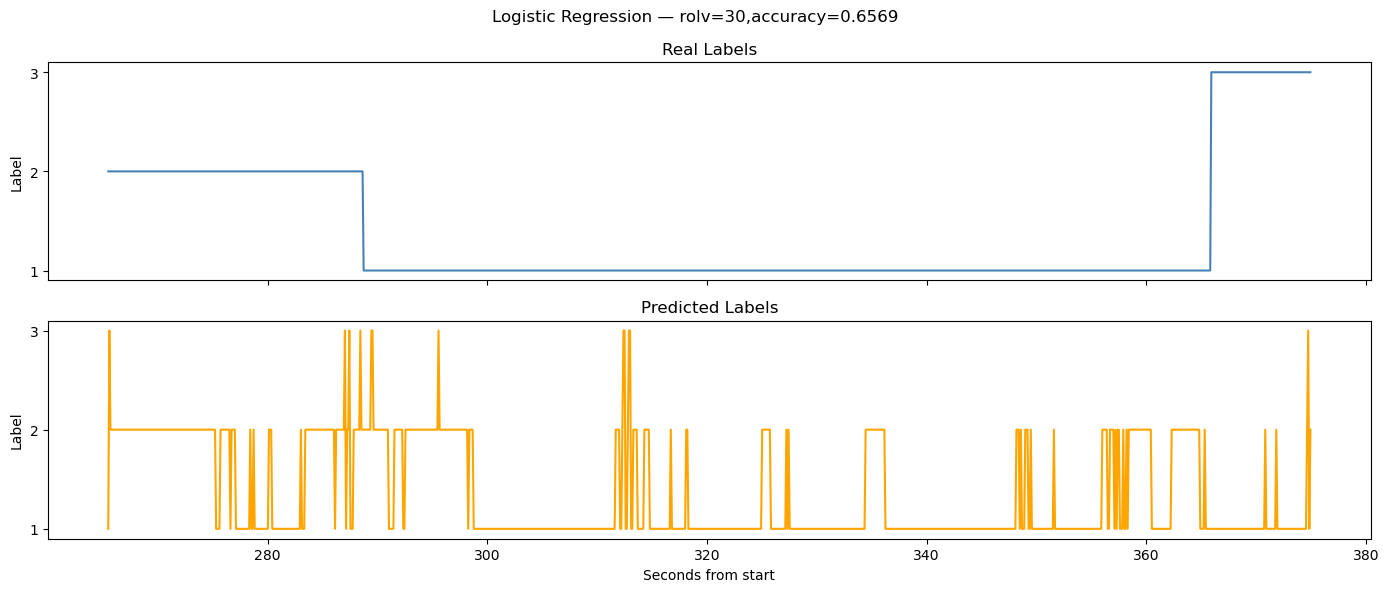

In [7]:
#model 1: logistic regression
lr_results=[]

#checks for rolling data window from 2-50 to check which window gives best accuracy
for rolv in range(2, 51):
    #training dataset
    train_df = X_train_raw.copy()
    train_df['label'] = y_train_raw #temporarily attach labels to the dataframe so they stay aligned with the rows after rolling drops NaN rows
    train_df = rollingdata(train_df, rolv) #call rolling function on train dataset with whatever rolv value its at rn
    X_train = train_df.drop(columns=['label']) #separate features and labels back out after rolling
    y_train = train_df['label'] 

    #testing dataset; same thing happens
    test_df = X_test_raw.copy()
    test_df['label'] = y_test_raw
    test_df = rollingdata(test_df, rolv)
    X_test = test_df.drop(columns=['label'])
    y_test = test_df['label']
     
    #pipeline to ensure X data is always scaled consistently for GridSearchCV
    lr_pipeline=Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(class_weight='balanced',random_state=42))
    ])

    #parameters to check on during GridSearchCV
    lr_grid={
        'lr__C': [30, 40, 50],
        'lr__max_iter': [300, 400, 500]
    }

    #tries every parameter combo, picks best by accuracy
    lr_search=GridSearchCV(lr_pipeline, lr_grid, cv=cv, scoring='accuracy',n_jobs=-1)
    lr_search.fit(X_train, y_train)
    best_lr=lr_search.best_estimator_ #Best parameter combo from GridSearchCV for tha specific rolv value

    #predict y values from X testing data and checked for accuracy to find best model
    y_pred = best_lr.predict(X_test)
    lr_results.append({'rolv': rolv,'LR_acc': accuracy_score(y_test, y_pred),'LR_best_params': lr_search.best_params_})

    print(f'rolv={rolv} done!')

#logistic regression results, one row per rolv for best paramter at that specific rolv value
lr_results_df = pd.DataFrame(lr_results)

#rolv and its params that result in highest test accuracy
best = lr_results_df.loc[lr_results_df['LR_acc'].idxmax()]
lr_best_params = best['LR_best_params']
lr_best_rolv = int(best['rolv'])
lr_best_C = lr_best_params['lr__C']
lr_best_max_iter = lr_best_params['lr__max_iter']

print("\nBEST LOGISTIC REGRESSION:")
print(f"rolv={lr_best_rolv}")
print(f"accuracy={best['LR_acc']:.4f}")
print(f"params={lr_best_params}")

#rebuild final model using best rolv and its params found from grid search
best_lr_final = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=lr_best_C, max_iter=lr_best_max_iter, class_weight='balanced',random_state=42))
])

#re-roll at best rolv — loop ends at rolv=50 so this step is required
train_df = X_train_raw.copy()
train_df['label'] = y_train_raw
train_df = rollingdata(train_df, lr_best_rolv)
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

test_df = X_test_raw.copy()
test_df['label'] = y_test_raw
test_df = rollingdata(test_df, lr_best_rolv)
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

best_lr_final.fit(X_train, y_train)
y_pred = best_lr_final.predict(X_test)

#convert timestamps to seconds from start for clean x-axis
timestamps_test = traintimeseries.loc[X_test.index,'timestamp']
t0 = traintimeseries['timestamp'].min()
timestamps_plot = (timestamps_test - t0) / 1000

#plot real vs predicted labels over time
fig, axes = plt.subplots(2, 1, figsize=(14, 6),sharex=True)

axes[0].plot(timestamps_plot, y_test.values, color='steelblue')
axes[0].set_title('Real Labels')
axes[0].set_ylabel('Label')
axes[0].set_yticks(sorted(y_test.unique()))

axes[1].plot(timestamps_plot, y_pred, color='orange')
axes[1].set_title('Predicted Labels')
axes[1].set_ylabel('Label')
axes[1].set_yticks(sorted(y_test.unique()))
axes[1].set_xlabel('Seconds from start')

plt.suptitle(f'Logistic Regression — rolv={lr_best_rolv},accuracy={accuracy_score(y_test, y_pred):.4f}')
plt.tight_layout()
plt.show()

rolv=2 done!
rolv=3 done!
rolv=4 done!
rolv=5 done!
rolv=6 done!
rolv=7 done!
rolv=8 done!
rolv=9 done!
rolv=10 done!
rolv=11 done!
rolv=12 done!
rolv=13 done!
rolv=14 done!
rolv=15 done!
rolv=16 done!
rolv=17 done!
rolv=18 done!
rolv=19 done!
rolv=20 done!
rolv=21 done!
rolv=22 done!
rolv=23 done!
rolv=24 done!
rolv=25 done!
rolv=26 done!
rolv=27 done!
rolv=28 done!
rolv=29 done!
rolv=30 done!
rolv=31 done!
rolv=32 done!
rolv=33 done!
rolv=34 done!
rolv=35 done!
rolv=36 done!
rolv=37 done!
rolv=38 done!
rolv=39 done!
rolv=40 done!
rolv=41 done!
rolv=42 done!
rolv=43 done!
rolv=44 done!
rolv=45 done!
rolv=46 done!
rolv=47 done!
rolv=48 done!
rolv=49 done!
rolv=50 done!

BEST DECISION TREE:
rolv=42
accuracy=0.7336
params={'max_depth': 10, 'min_samples_split': 2}


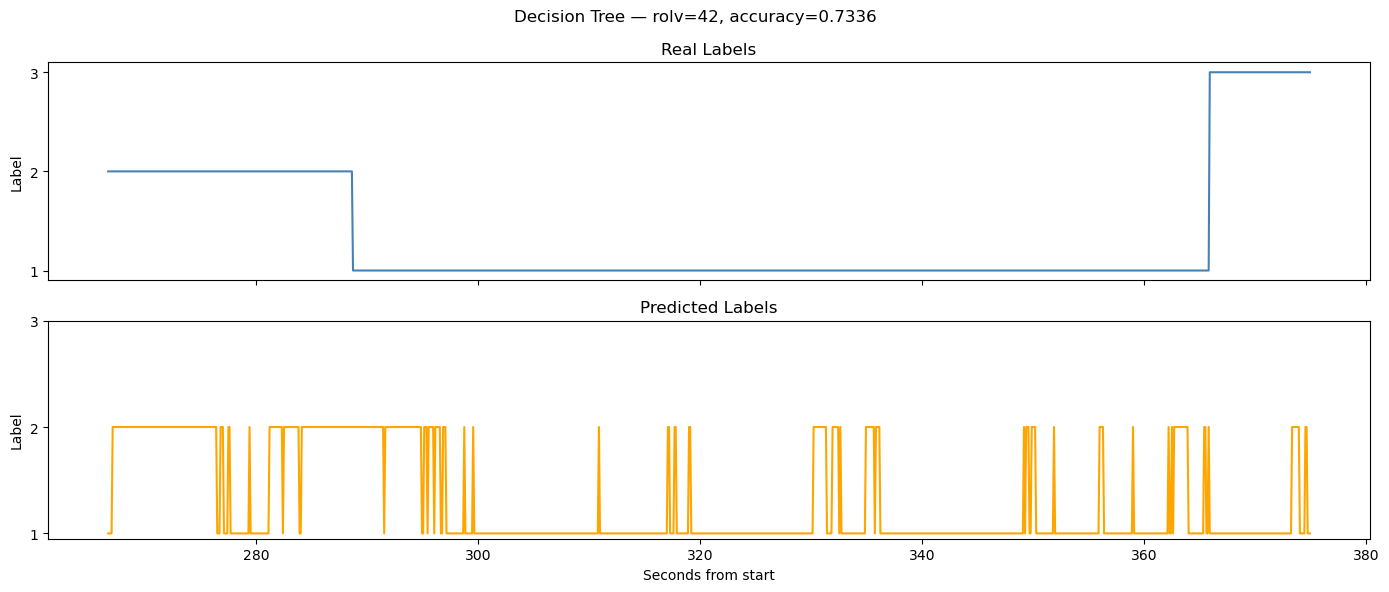

In [8]:
#model 2: decision Tree

dt_results = []

#same format as logistic regression: sweep rolv, run GridSearchCV, record best result
for rolv in range(2, 51):

    train_df = X_train_raw.copy()
    train_df['label'] = y_train_raw
    train_df = rollingdata(train_df, rolv)
    X_train = train_df.drop(columns=['label'])
    y_train = train_df['label']

    test_df = X_test_raw.copy()
    test_df['label'] = y_test_raw
    test_df = rollingdata(test_df, rolv)
    X_test = test_df.drop(columns=['label'])
    y_test = test_df['label']

    dt_grid={
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5]
    }

    dt_search = GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        dt_grid,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    dt_search.fit(X_train, y_train)
    best_dt = dt_search.best_estimator_

    y_pred = best_dt.predict(X_test)

    dt_results.append({
        'rolv': rolv,
        'DT_acc': accuracy_score(y_test, y_pred),
        'DT_best_params': dt_search.best_params_
    })

    print(f'rolv={rolv} done!')

dt_results_df = pd.DataFrame(dt_results)

best = dt_results_df.loc[dt_results_df['DT_acc'].idxmax()]

dt_best_params = best['DT_best_params']

dt_best_rolv = int(best['rolv'])
dt_best_max_depth = dt_best_params['max_depth']
dt_best_min_samples_split = dt_best_params['min_samples_split']

print("\nBEST DECISION TREE:")
print(f"rolv={dt_best_rolv}")
print(f"accuracy={best['DT_acc']:.4f}")
print(f"params={dt_best_params}")

#best decision tree model
best_dt_final = DecisionTreeClassifier(max_depth=dt_best_max_depth, min_samples_split=dt_best_min_samples_split, random_state=42)

#re-roll at best rolv and evaluate final model on test set
train_df = X_train_raw.copy()
train_df['label'] = y_train_raw
train_df = rollingdata(train_df, dt_best_rolv)
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

test_df = X_test_raw.copy()
test_df['label'] = y_test_raw
test_df = rollingdata(test_df, dt_best_rolv)
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

best_dt_final.fit(X_train, y_train)
y_pred = best_dt_final.predict(X_test)

timestamps_test = traintimeseries.loc[X_test.index, 'timestamp']
t0 = traintimeseries['timestamp'].min()
timestamps_plot = (timestamps_test - t0) / 1000

#plot
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(timestamps_plot, y_test.values, color='steelblue')
axes[0].set_title('Real Labels')
axes[0].set_ylabel('Label')
axes[0].set_yticks(sorted(y_test.unique()))

axes[1].plot(timestamps_plot, y_pred, color='orange')
axes[1].set_title('Predicted Labels')
axes[1].set_ylabel('Label')
axes[1].set_yticks(sorted(y_test.unique()))
axes[1].set_xlabel('Seconds from start')

plt.suptitle(f'Decision Tree — rolv={dt_best_rolv}, accuracy={accuracy_score(y_test, y_pred):.4f}')
plt.tight_layout()
plt.show()

rolv=2 done!
rolv=3 done!
rolv=4 done!
rolv=5 done!
rolv=6 done!
rolv=7 done!
rolv=8 done!
rolv=9 done!
rolv=10 done!
rolv=11 done!
rolv=12 done!
rolv=13 done!
rolv=14 done!
rolv=15 done!
rolv=16 done!
rolv=17 done!
rolv=18 done!
rolv=19 done!
rolv=20 done!
rolv=21 done!
rolv=22 done!
rolv=23 done!
rolv=24 done!
rolv=25 done!
rolv=26 done!
rolv=27 done!
rolv=28 done!
rolv=29 done!
rolv=30 done!
rolv=31 done!
rolv=32 done!
rolv=33 done!
rolv=34 done!
rolv=35 done!
rolv=36 done!
rolv=37 done!
rolv=38 done!
rolv=39 done!
rolv=40 done!
rolv=41 done!
rolv=42 done!
rolv=43 done!
rolv=44 done!
rolv=45 done!
rolv=46 done!
rolv=47 done!
rolv=48 done!
rolv=49 done!
rolv=50 done!

BEST RANDOM FOREST:
rolv=40
accuracy=0.7608
params={'max_depth': None, 'min_samples_split': 3, 'n_estimators': 150}


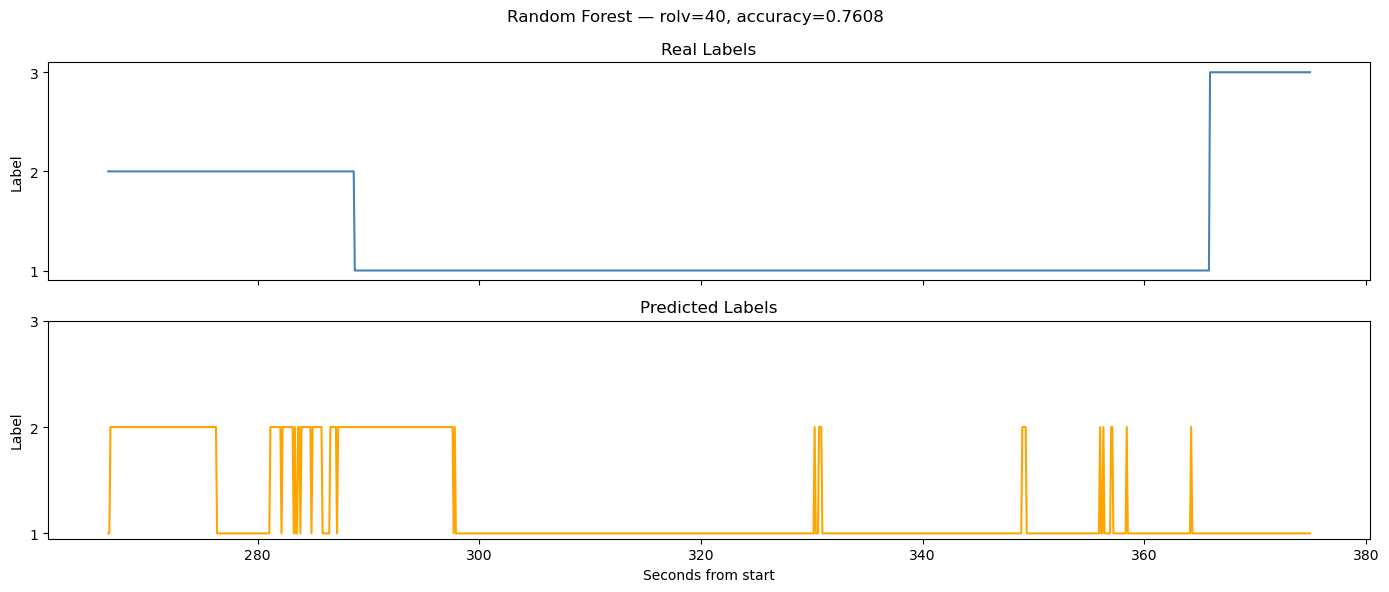

In [9]:
rf_results = []

#same format as previous models
for rolv in range(2, 51):

    train_df = X_train_raw.copy()
    train_df['label'] = y_train_raw
    train_df = rollingdata(train_df, rolv)

    test_df = X_test_raw.copy()
    test_df['label'] = y_test_raw
    test_df = rollingdata(test_df, rolv)

    X_train = train_df.drop(columns=['label'])
    y_train = train_df['label']
    X_test = test_df.drop(columns=['label'])
    y_test = test_df['label']

    rf_grid={
        'n_estimators': [50, 100, 150],
        'max_depth': [None, 5, 10],
        'min_samples_split': [3, 4, 5]
    }

    rf_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        rf_grid,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    rf_search.fit(X_train, y_train)
    best_rf = rf_search.best_estimator_

    y_pred = best_rf.predict(X_test)

    rf_results.append({
        'rolv': rolv,
        'RF_acc': accuracy_score(y_test, y_pred),
        'RF_best_params': rf_search.best_params_
    })
    
    print(f'rolv={rolv} done!')

rf_results_df = pd.DataFrame(rf_results)

best = rf_results_df.loc[rf_results_df['RF_acc'].idxmax()]

rf_best_params = best['RF_best_params']

rf_best_rolv = int(best['rolv'])
rf_best_max_depth = rf_best_params['max_depth']
rf_best_min_samples_split = rf_best_params['min_samples_split']
rf_best_n_estimators = rf_best_params['n_estimators']

print("\nBEST RANDOM FOREST:")
print(f"rolv={rf_best_rolv}")
print(f"accuracy={best['RF_acc']:.4f}")
print(f"params={best['RF_best_params']}")

#best random forest model
best_rf_final = RandomForestClassifier(n_estimators=rf_best_n_estimators, max_depth=rf_best_max_depth, min_samples_split=rf_best_min_samples_split, random_state=42)

#re-roll at best rolv and evaluate final model on test set
train_df = X_train_raw.copy()
train_df['label'] = y_train_raw
train_df = rollingdata(train_df, rf_best_rolv)
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

test_df = X_test_raw.copy()
test_df['label'] = y_test_raw
test_df = rollingdata(test_df, rf_best_rolv)
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

best_rf_final.fit(X_train, y_train)
y_pred = best_rf_final.predict(X_test)

timestamps_test = traintimeseries.loc[X_test.index, 'timestamp']
t0 = traintimeseries['timestamp'].min()
timestamps_plot = (timestamps_test - t0) / 1000

#plot
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(timestamps_plot, y_test.values, color='steelblue')
axes[0].set_title('Real Labels')
axes[0].set_ylabel('Label')
axes[0].set_yticks(sorted(y_test.unique()))

axes[1].plot(timestamps_plot, y_pred, color='orange')
axes[1].set_title('Predicted Labels')
axes[1].set_ylabel('Label')
axes[1].set_yticks(sorted(y_test.unique()))
axes[1].set_xlabel('Seconds from start')

plt.suptitle(f'Random Forest — rolv={rf_best_rolv}, accuracy={accuracy_score(y_test, y_pred):.4f}')
plt.tight_layout()
plt.show()

rolv=2 done!
rolv=3 done!
rolv=4 done!
rolv=5 done!
rolv=6 done!
rolv=7 done!
rolv=8 done!
rolv=9 done!
rolv=10 done!
rolv=11 done!
rolv=12 done!
rolv=13 done!
rolv=14 done!
rolv=15 done!
rolv=16 done!
rolv=17 done!
rolv=18 done!
rolv=19 done!
rolv=20 done!
rolv=21 done!
rolv=22 done!
rolv=23 done!
rolv=24 done!
rolv=25 done!
rolv=26 done!
rolv=27 done!
rolv=28 done!
rolv=29 done!
rolv=30 done!
rolv=31 done!
rolv=32 done!
rolv=33 done!
rolv=34 done!
rolv=35 done!
rolv=36 done!
rolv=37 done!
rolv=38 done!
rolv=39 done!
rolv=40 done!
rolv=41 done!
rolv=42 done!
rolv=43 done!
rolv=44 done!
rolv=45 done!
rolv=46 done!
rolv=47 done!
rolv=48 done!
rolv=49 done!
rolv=50 done!

BEST XGBOOST:
rolv=43
accuracy=0.7111
params={'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}


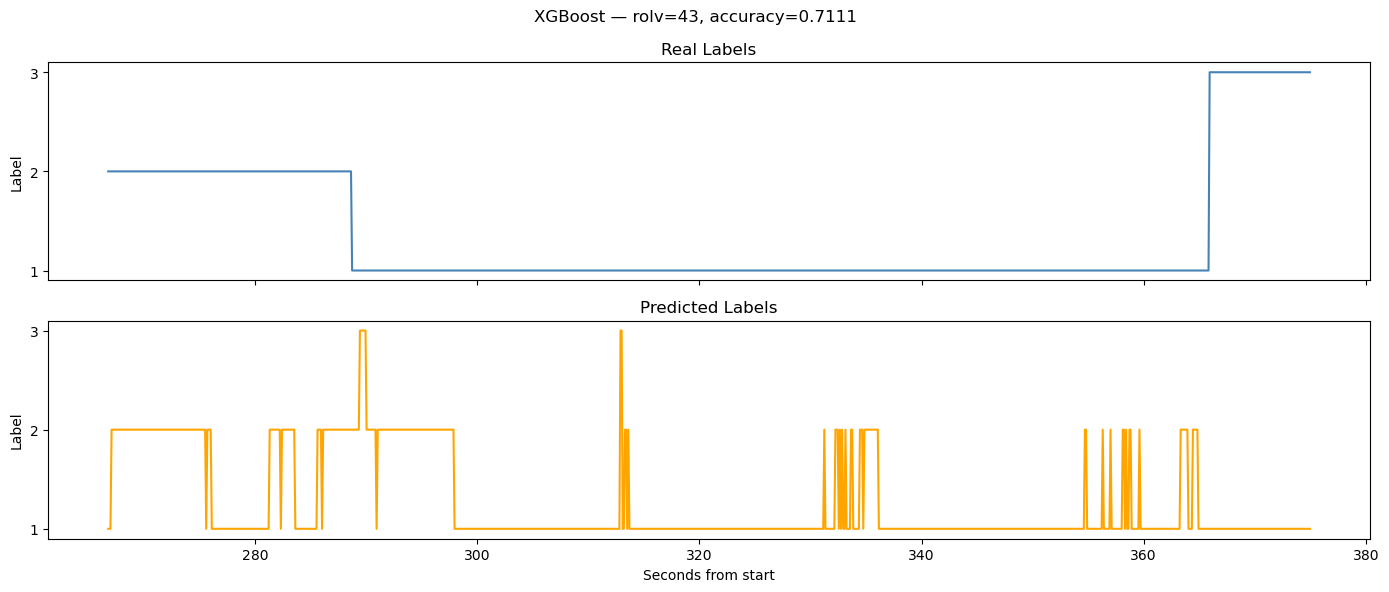

In [10]:
from xgboost import XGBClassifier

xgb_results = []

#same format as previous models
for rolv in range(2, 51):

    train_df = X_train_raw.copy()
    train_df['label'] = y_train_raw
    train_df = rollingdata(train_df, rolv)

    test_df = X_test_raw.copy()
    test_df['label'] = y_test_raw
    test_df = rollingdata(test_df, rolv)

    X_train = train_df.drop(columns=['label'])
    y_train = train_df['label']
    X_test = test_df.drop(columns=['label'])
    y_test = test_df['label']

    xgb_grid={
        'n_estimators': [100, 200, 300],
        'max_depth': [2, 3, 6],
        'learning_rate': [0.05, 0.1]
    }

    xgb_search = GridSearchCV(
        XGBClassifier(eval_metric='mlogloss', random_state=42),
        xgb_grid,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    xgb_search.fit(X_train, y_train)
    best_xgb = xgb_search.best_estimator_

    y_pred = best_xgb.predict(X_test)

    xgb_results.append({
        'rolv': rolv,
        'XGB_acc': accuracy_score(y_test, y_pred),
        'XGB_best_params': xgb_search.best_params_
    })
    print(f'rolv={rolv} done!')

xgb_results_df = pd.DataFrame(xgb_results)

best = xgb_results_df.loc[xgb_results_df['XGB_acc'].idxmax()]

xgb_best_params = best['XGB_best_params']

xgb_best_rolv = int(best['rolv'])
xgb_best_learning_rate = xgb_best_params['learning_rate']
xgb_best_max_depth = xgb_best_params['max_depth']
xgb_n_estimators = xgb_best_params['n_estimators']

print("\nBEST XGBOOST:")
print(f"rolv={xgb_best_rolv}")
print(f"accuracy={best['XGB_acc']:.4f}")
print(f"params={xgb_best_params}")

#best xgboost model
best_xgb_final = XGBClassifier(n_estimators=xgb_n_estimators, max_depth=xgb_best_max_depth, learning_rate=xgb_best_learning_rate, eval_metric='mlogloss', random_state=42)

#re-roll at best rolv and evaluate final model on test set
train_df = X_train_raw.copy()
train_df['label'] = y_train_raw
train_df = rollingdata(train_df, xgb_best_rolv)
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

test_df = X_test_raw.copy()
test_df['label'] = y_test_raw
test_df = rollingdata(test_df, xgb_best_rolv)
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

best_xgb_final.fit(X_train, y_train)
y_pred = best_xgb_final.predict(X_test)

timestamps_test = traintimeseries.loc[X_test.index, 'timestamp']
t0 = traintimeseries['timestamp'].min()
timestamps_plot = (timestamps_test - t0) / 1000

#plot
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(timestamps_plot, y_test.values, color='steelblue')
axes[0].set_title('Real Labels')
axes[0].set_ylabel('Label')
axes[0].set_yticks(sorted(y_test.unique()))

axes[1].plot(timestamps_plot, y_pred, color='orange')
axes[1].set_title('Predicted Labels')
axes[1].set_ylabel('Label')
axes[1].set_yticks(sorted(y_test.unique()))
axes[1].set_xlabel('Seconds from start')

plt.suptitle(f'XGBoost — rolv={xgb_best_rolv}, accuracy={accuracy_score(y_test, y_pred):.4f}')
plt.tight_layout()
plt.show()

In [11]:
#summary table comparing best results across all 4 models
summary = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Best Accuracy': lr_results_df['LR_acc'].max(),
        'Best rolv': lr_best_rolv,
        'Best Params': str(lr_best_params)
    },
    {
        'Model': 'Decision Tree',
        'Best Accuracy': dt_results_df['DT_acc'].max(),
        'Best rolv': dt_best_rolv,
        'Best Params': str(dt_best_params)
    },
    {
        'Model': 'Random Forest',
        'Best Accuracy': rf_results_df['RF_acc'].max(),
        'Best rolv': rf_best_rolv,
        'Best Params': str(rf_best_params)
    },
    {
        'Model': 'XGBoost',
        'Best Accuracy': xgb_results_df['XGB_acc'].max(),
        'Best rolv': xgb_best_rolv,
        'Best Params': str(xgb_best_params)
    },
])

summary = summary.sort_values('Best Accuracy', ascending=False).reset_index(drop=True)
summary

,Model,Best Accuracy,Best rolv,Best Params
0,Random Forest,0.760849,40,"{'max_depth': None, 'min_samples_split': 3, 'n..."
1,Decision Tree,0.733580,42,"{'max_depth': 10, 'min_samples_split': 2}"
2,XGBoost,0.711111,43,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti..."
3,Logistic Regression,0.656908,30,"{'lr__C': 50, 'lr__max_iter': 300}"


## Test Set Predictions

Rolling features are applied directly to `testtimeseries` at each model's best `rolv`. Predictions from all four models are plotted against time, and the best model's predictions (Random Forest) are exported to `test_labels.csv`.

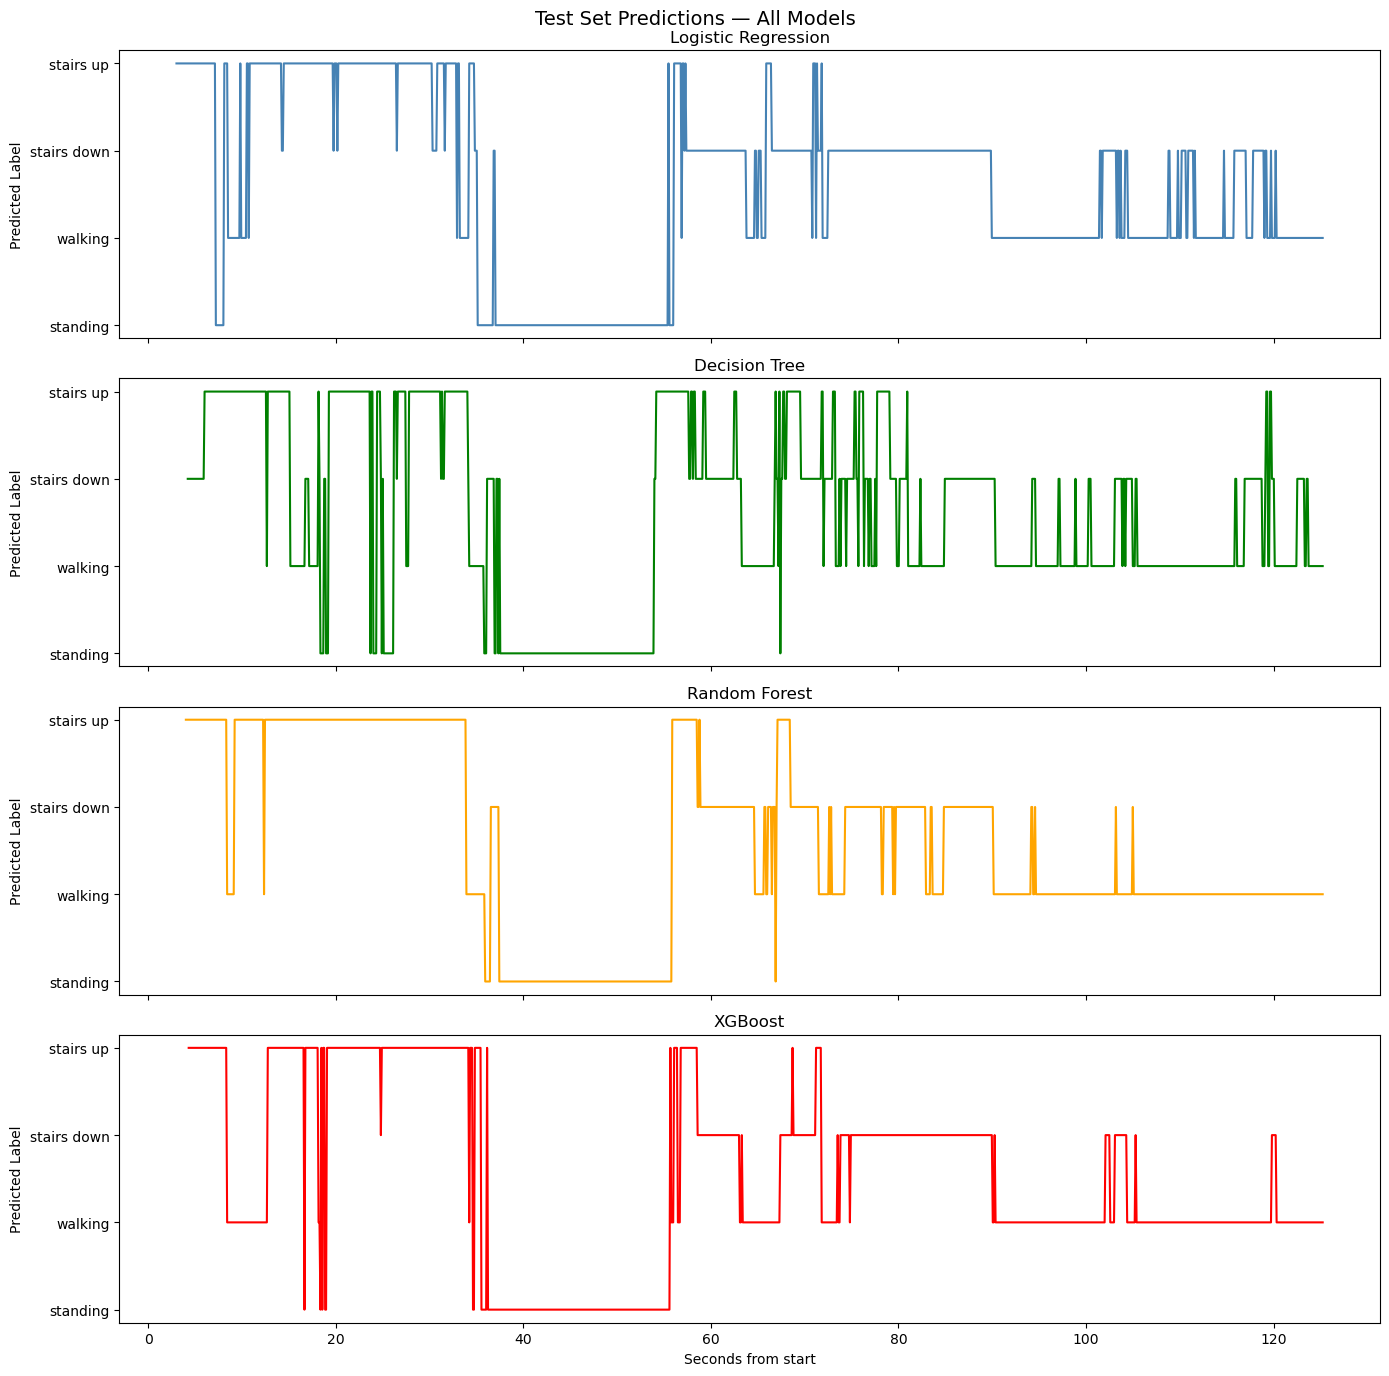

In [12]:
#prepare test data from testtimeseries for prediction
#drop unneeded columns
test_df = testtimeseries.drop(columns=['UTC time', 'accuracy']).copy()
X_pred = test_df.drop(columns=['timestamp'])

test_rolled_lr  = rollingdata(X_pred, lr_best_rolv)
test_rolled_dt  = rollingdata(X_pred, dt_best_rolv)
test_rolled_rf  = rollingdata(X_pred, rf_best_rolv)
test_rolled_xgb = rollingdata(X_pred, xgb_best_rolv)

y_pred_lr  = best_lr_final.predict(test_rolled_lr)
y_pred_dt  = best_dt_final.predict(test_rolled_dt)
y_pred_rf  = best_rf_final.predict(test_rolled_rf)
y_pred_xgb = best_xgb_final.predict(test_rolled_xgb)

#convert timestamps to seconds from start for clean x-axis
t0 = testtimeseries['timestamp'].min()

#each model drops first rolv-1 rows so align timestamps to tail of testtimeseries
ts_lr  = (testtimeseries['timestamp'].iloc[len(testtimeseries) - len(y_pred_lr):].values  - t0) / 1000
ts_dt  = (testtimeseries['timestamp'].iloc[len(testtimeseries) - len(y_pred_dt):].values  - t0) / 1000
ts_rf  = (testtimeseries['timestamp'].iloc[len(testtimeseries) - len(y_pred_rf):].values  - t0) / 1000
ts_xgb = (testtimeseries['timestamp'].iloc[len(testtimeseries) - len(y_pred_xgb):].values - t0) / 1000

#plot all 4 model predictions over time
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

models = [
    (ts_lr,  y_pred_lr,  'Logistic Regression', 'steelblue'),
    (ts_dt,  y_pred_dt,  'Decision Tree',        'green'),
    (ts_rf,  y_pred_rf,  'Random Forest',        'orange'),
    (ts_xgb, y_pred_xgb, 'XGBoost',              'red'),
]

for ax, (ts, y_pred, title, color) in zip(axes, models):
    ax.plot(ts, y_pred, color=color)
    ax.set_title(title)
    ax.set_ylabel('Predicted Label')
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(['standing', 'walking', 'stairs down', 'stairs up'])

axes[-1].set_xlabel('Seconds from start')
plt.suptitle('Test Set Predictions — All Models', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# match RF predictions back to testlabels by timestamp and export
ts_rf = testtimeseries['timestamp'].iloc[len(testtimeseries) - len(y_pred_rf):]

testlabels['label'] = pd.Series(le.inverse_transform(y_pred_rf).astype(int), index=ts_rf.index).reindex(testlabels.index)

testlabels.to_csv('test_labels.csv', index=False)
print('Saved test_labels.csv')
testlabels

Saved test_labels.csv


,UTC time,label
timestamp,,
1565110307041,2019-08-06T16:51:47.041,NaN
1565110308043,2019-08-06T16:51:48.043,NaN
1565110309046,2019-08-06T16:51:49.046,NaN
1565110310048,2019-08-06T16:51:50.048,NaN
1565110311050,2019-08-06T16:51:51.050,NaN
...,...,...
1565110427366,2019-08-06T16:53:47.366,NaN
1565110428369,2019-08-06T16:53:48.369,NaN
1565110429371,2019-08-06T16:53:49.371,NaN


In [14]:
#note: the first few rows of testlabels will have NaN labels since they fall within the first rolling window and are dropped by rollingdata()